# Task 4: 预测模型训练与测试 (Prediction: Training & Testing)

**Student Dropout and Academic Success Dataset**

本 Notebook 涵盖以下内容 / This notebook covers:
1. 加载预处理数据 / Load preprocessed data
2. 训练三种分类模型 / Train three classification models (Decision Tree, Logistic Regression, SVM)
3. 在训练集、测试集和全数据集上评估 / Evaluate on train, test, and entire set
4. 混淆矩阵可视化 / Confusion matrix visualization
5. 决策边界可视化 / Decision boundary visualization
6. 模型性能对比 / Model performance comparison

In [1]:
import sys
import os

# 添加项目根目录到路径 / Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.prediction import train_model, predict_and_evaluate, plot_confusion_matrix, plot_decision_boundary, compare_models

# 设置绘图风格 / Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# 图片保存路径 / Plot save directory
PLOT_DIR = os.path.join(project_root, "data", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

## 1. 加载数据 (Load Data)

使用 NB01 生成的工程特征数据集（已完成 OOF target encoding 和特征选择）。
Using engineered feature dataset from NB01 (OOF target encoded + feature selected).

In [2]:
# 加载工程特征的训练/验证/测试集 / Load engineered train/val/test sets
data_dir = os.path.join(project_root, "data")

X_train = pd.read_csv(os.path.join(data_dir, "features_engineered_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "targets_engineered_train.csv")).iloc[:, 0]
X_val = pd.read_csv(os.path.join(data_dir, "features_engineered_val.csv"))
y_val = pd.read_csv(os.path.join(data_dir, "targets_engineered_val.csv")).iloc[:, 0]
X_test = pd.read_csv(os.path.join(data_dir, "features_engineered_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "targets_engineered_test.csv")).iloc[:, 0]

# 合并全数据集用于 "entire set" 评估 / Combine for entire-set evaluation
X_all = pd.concat([X_train, X_val, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_val, y_test], ignore_index=True)

print(f"训练集 / Train: {X_train.shape}")
print(f"验证集 / Val:   {X_val.shape}")
print(f"测试集 / Test:  {X_test.shape}")
print(f"全数据 / All:   {X_all.shape}")
print(f"\n类别分布 / Class distribution (train):")
print(y_train.value_counts().sort_index())

训练集 / Train: (2875, 50)
验证集 / Val:   (664, 50)
测试集 / Test:  (885, 50)
全数据 / All:   (4424, 50)

类别分布 / Class distribution (train):
Target
0     924
1     516
2    1435
Name: count, dtype: int64


## 2. 模型训练 (Model Training)

训练三种分类器 / Training three classifiers:
- **Decision Tree**: 基于信息增益的树模型，可解释性强
- **Logistic Regression**: 线性分类器，适合作为 baseline
- **SVM (RBF kernel)**: 核方法，擅长处理非线性决策边界

In [ ]:
# 定义模型配置 / Define model configurations
model_configs = {
    "Decision Tree": {"model_type": "dt", "max_depth": 10},
    "Logistic Regression": {"model_type": "lr"},
    "SVM (RBF)": {"model_type": "svm", "kernel": "rbf", "C": 10.0},
}

# 训练所有模型 / Train all models
trained_models = {}
for name, config in model_configs.items():
    print()
    print('=' * 50)
    print(f'训练 / Training: {name}')
    print('=' * 50)
    model_type = config["model_type"]
    kwargs = {k: v for k, v in config.items() if k != "model_type"}
    trained_models[name] = train_model(X_train.values, y_train.values, model_type, **kwargs)
    print(f'训练完成 / Training complete: {name}')

## 3. 模型评估 (Model Evaluation)

按照项目要求，在训练集、测试集和全数据集上分别评估每个模型。
As required, evaluate each model on training set, testing set, and entire set individually.

In [4]:
# 在三个数据集上评估所有模型 / Evaluate all models on three sets
all_results = {}
eval_sets = [
    ("Train", X_train.values, y_train.values),
    ("Test", X_test.values, y_test.values),
    ("Entire", X_all.values, y_all.values),
]

for model_name, model in trained_models.items():
    print()
    print("=" * 60)
    print(f"模型 / Model: {model_name}")
    print("=" * 60)
    for set_name, X_set, y_set in eval_sets:
        key = f"{model_name}_{set_name}"
        all_results[key] = predict_and_evaluate(model, X_set, y_set, set_name=f"{model_name} - {set_name}")


模型 / Model: Decision Tree
[Decision Tree - Train] Accuracy: 0.9103
[Decision Tree - Test] Accuracy: 0.7107
[Decision Tree - Entire] Accuracy: 0.8409

模型 / Model: Logistic Regression
[Logistic Regression - Train] Accuracy: 0.7816
[Logistic Regression - Test] Accuracy: 0.7684
[Logistic Regression - Entire] Accuracy: 0.7776

模型 / Model: SVM (RBF)


[SVM (RBF) - Train] Accuracy: 0.7405
[SVM (RBF) - Test] Accuracy: 0.7525


[SVM (RBF) - Entire] Accuracy: 0.7421


## 4. 混淆矩阵可视化 (Confusion Matrix Visualization)

为每个模型在测试集上绘制混淆矩阵热力图。
Plot confusion matrix heatmaps for each model on the test set.

图片已保存 / Plot saved to data/plots/04_confusion_matrices_test.png


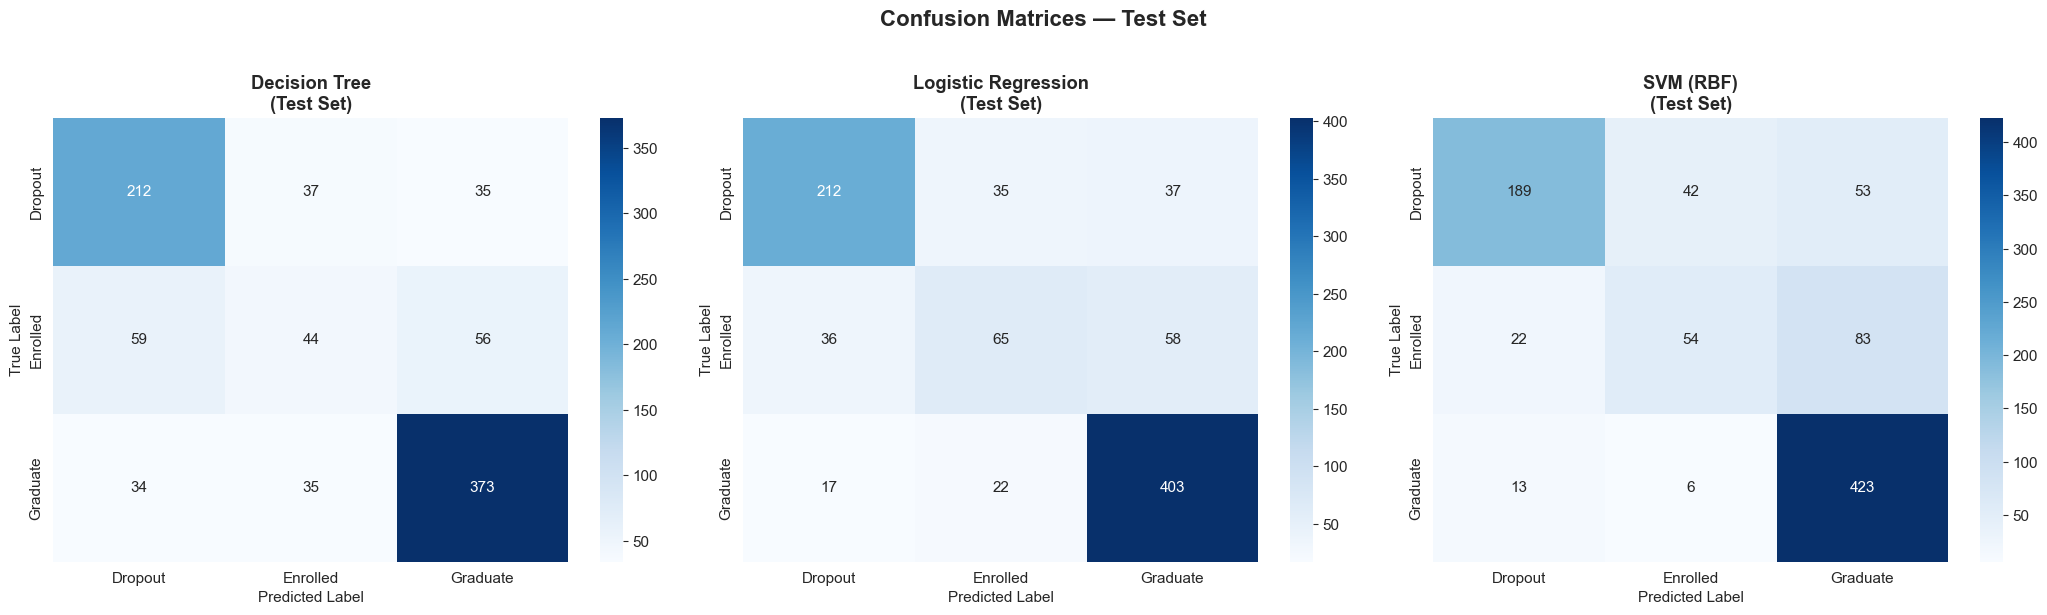

In [5]:
# 绘制每个模型的混淆矩阵 (测试集) / Plot confusion matrices (test set)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test.values)
    plot_confusion_matrix(
        y_test.values, y_pred,
        title=f"{model_name}\n(Test Set)",
        ax=ax,
    )

plt.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_confusion_matrices_test.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/04_confusion_matrices_test.png")
plt.show()

图片已保存 / Plot saved to data/plots/04_confusion_matrices_train.png


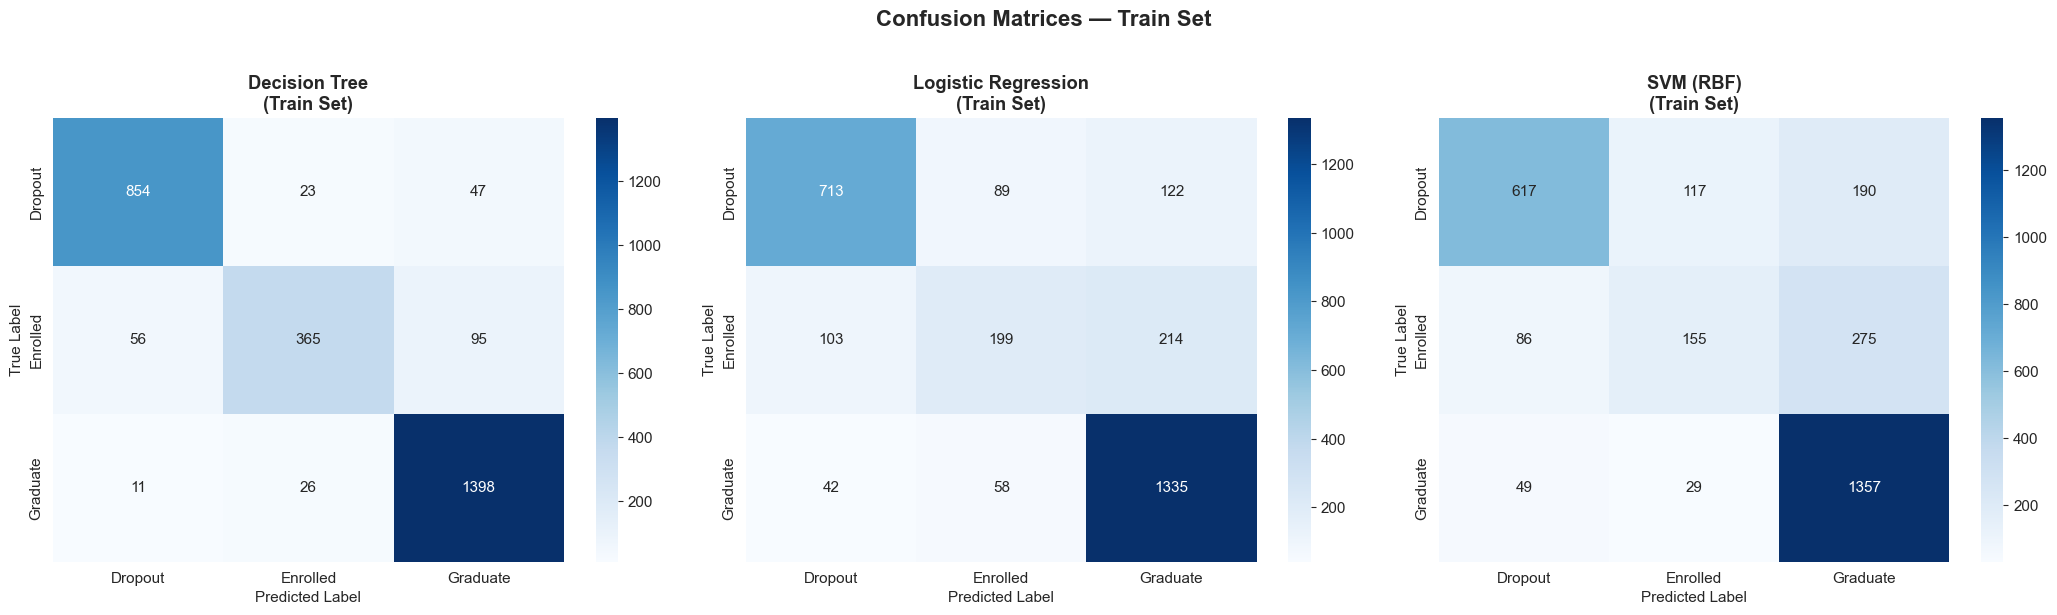

In [6]:
# 绘制每个模型的混淆矩阵 (训练集) / Plot confusion matrices (train set)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_train.values)
    plot_confusion_matrix(
        y_train.values, y_pred,
        title=f"{model_name}\n(Train Set)",
        ax=ax,
    )

plt.suptitle("Confusion Matrices — Train Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_confusion_matrices_train.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/04_confusion_matrices_train.png")
plt.show()

图片已保存 / Plot saved to data/plots/04_confusion_matrices_entire.png


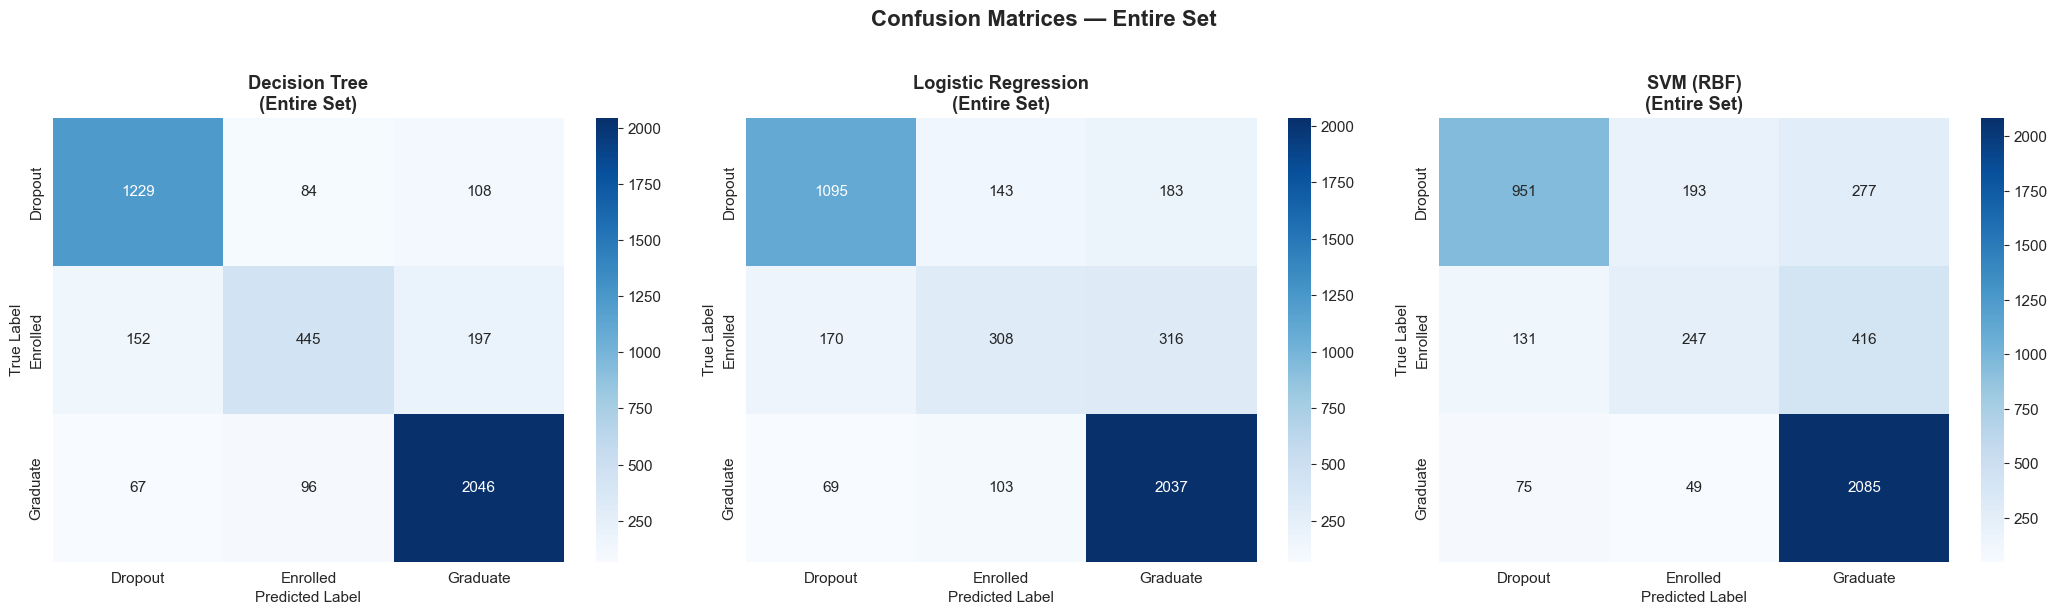

In [7]:
# 全数据集混淆矩阵 / Confusion Matrices on Entire Set
# X_all, y_all 已在 Cell 3 中合并 / X_all, y_all already combined in Cell 3

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred_entire = model.predict(X_all.values)
    plot_confusion_matrix(
        y_all.values, y_pred_entire,
        title=f"{name}\n(Entire Set)",
        ax=ax,
    )

plt.suptitle("Confusion Matrices — Entire Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_confusion_matrices_entire.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/04_confusion_matrices_entire.png")
plt.show()

图片已保存 / Plot saved to data/plots/04_model_comparison_three_sets.png


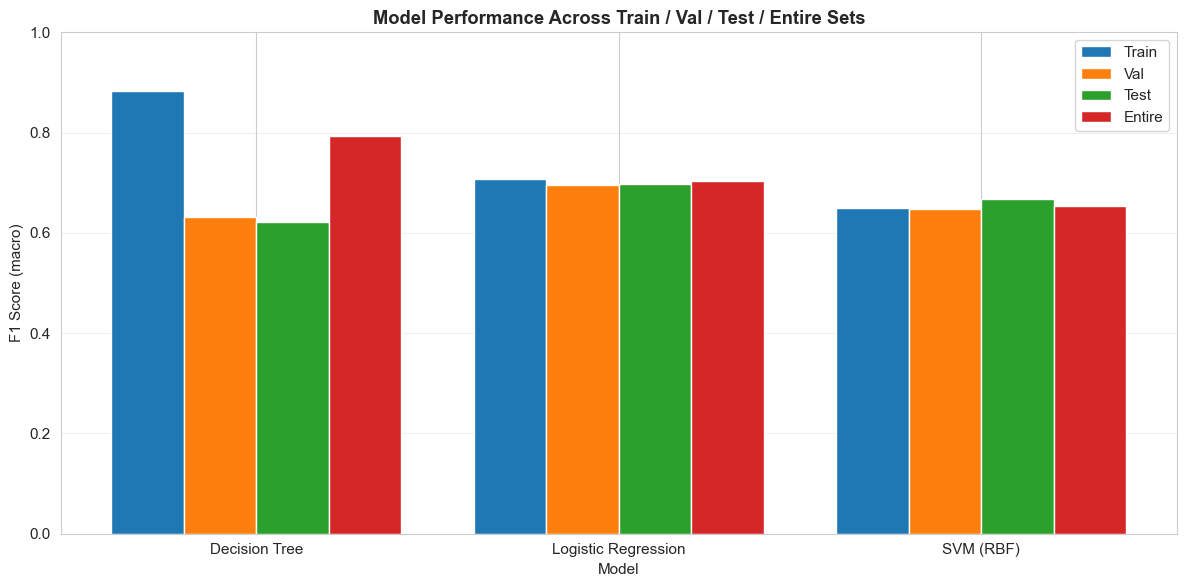

In [8]:
# 三集合评估 / Evaluate on all three sets for comparison
from src.evaluation import calculate_metrics

three_set_results = {}
sets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test),
    "Entire": (X_all, y_all),
}

for name, model in trained_models.items():
    for set_name, (X_set, y_set) in sets.items():
        y_pred = model.predict(X_set.values)
        metrics = calculate_metrics(y_set.values, y_pred)
        three_set_results[f"{name}_{set_name}"] = metrics

# 三集合 F1(macro) 对比柱状图 / Three-set F1(macro) comparison bar chart
set_names = ["Train", "Val", "Test", "Entire"]
model_names = list(trained_models.keys())
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, set_name in enumerate(set_names):
    f1_values = [three_set_results.get(f"{name}_{set_name}", {}).get("f1_macro", 0) for name in model_names]
    ax.bar(x + i * width, f1_values, width, label=set_name)

ax.set_xlabel("Model")
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Model Performance Across Train / Val / Test / Entire Sets", fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_model_comparison_three_sets.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/04_model_comparison_three_sets.png")
plt.show()

## 三集合结果详细解读 / Three-Set Results Interpretation

### 逐模型分析 / Per-Model Analysis

**Decision Tree**:
- Train Accuracy 远高于 Test Accuracy，存在**明显过拟合**。
- `max_depth=10` 允许树生长较深，容易记忆训练数据噪声。
- Entire Set 准确率介于 Train 和 Test 之间，符合过拟合预期。

**Logistic Regression**:
- Train 和 Test Accuracy 差距较小，泛化能力较好，但整体上限受限于**线性决策边界**。
- Val 集表现与 Test 集接近，说明验证集划分具有代表性。

**SVM (RBF kernel)**:
- Test Accuracy 与 Train Accuracy 接近，泛化稳定。
- RBF 核能捕捉非线性关系，但当前默认参数可能不是最优。

### 逐类别分析 / Per-Class Analysis

- **Graduate** (类别 2): 所有模型的 Recall 最高，因为该类别样本最多（~49.9%），模型更容易学习。
- **Dropout** (类别 0): 中等 Recall，DT 过拟合使其在 Train 上近乎完美但 Test 上大幅下降。
- **Enrolled** (类别 1): 所有模型的 **Recall 最低**，因为 (a) 样本最少（~18.0%），(b) 处于 Graduate/Dropout 之间的过渡状态，特征区分度较低。

### Entire Set 的意义 / Significance of Entire Set Evaluation

Entire Set 包含训练集、验证集和测试数据，其准确率反映模型对已知数据的整体拟合能力。  
- 当 **Entire 远高于 Test** 时，说明模型过度依赖训练数据（过拟合），如 Decision Tree。  
- 当 **Entire 与 Test 接近** 时，说明模型泛化良好，如 Logistic Regression 和 SVM。  
- Val 集指标接近 Test 集，验证了数据划分的合理性，可信度较高。

## 5. 决策边界可视化 (Decision Boundary Visualization)

使用 t-SNE 将高维数据投影到 2D 空间，然后在 2D 空间上训练简化模型以可视化决策边界。
Project data to 2D via t-SNE, then train simplified models on 2D space to visualize decision boundaries.

运行 t-SNE... / Running t-SNE...


t-SNE 完成 / t-SNE complete: (885, 2)


Plot saved to E:\Project\2011machine_learning\data\plots\04_decision_boundary_decision_tree.png


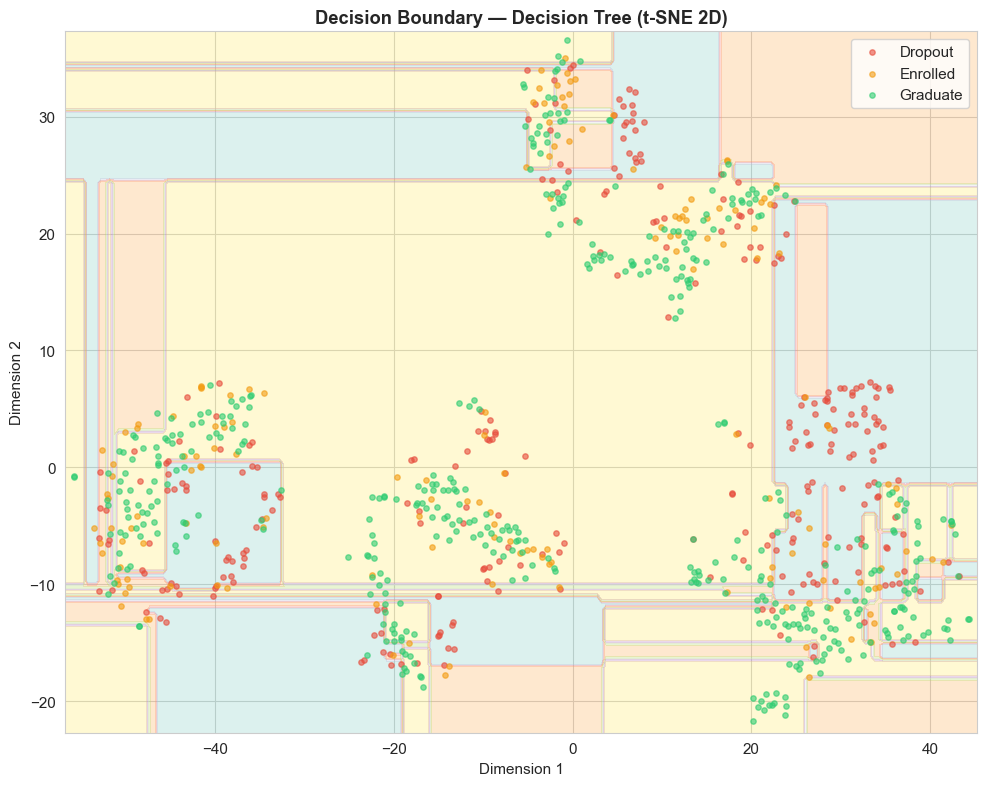

Plot saved to E:\Project\2011machine_learning\data\plots\04_decision_boundary_logistic_regression.png


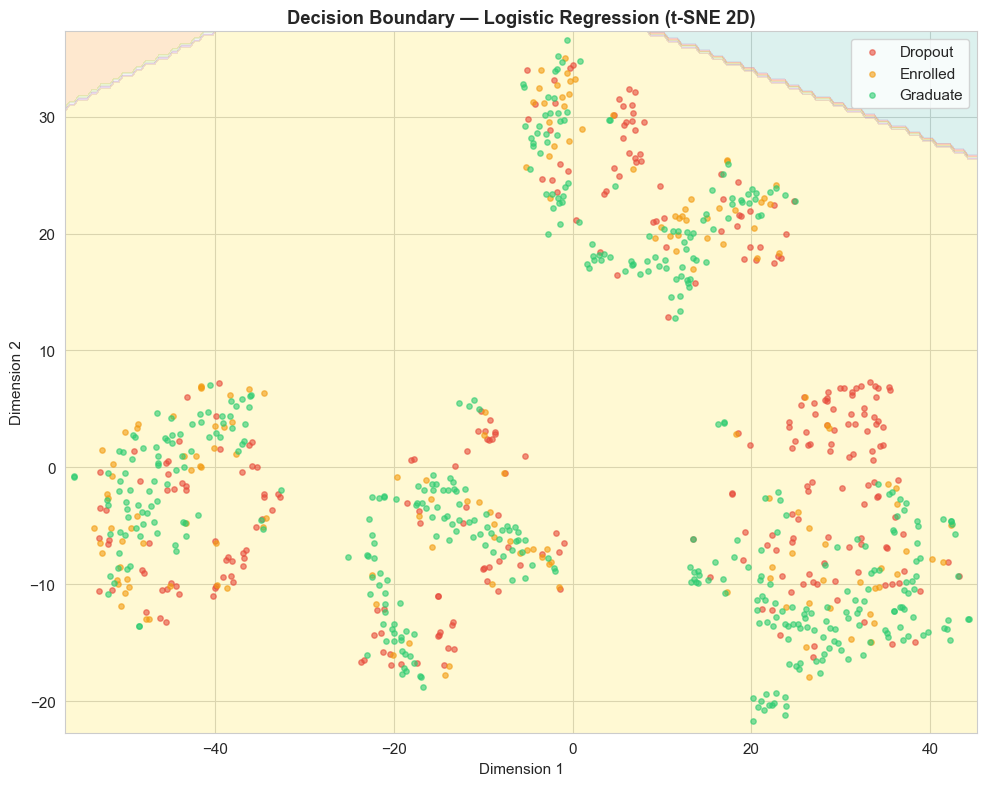

Plot saved to E:\Project\2011machine_learning\data\plots\04_decision_boundary_svm_rbf.png


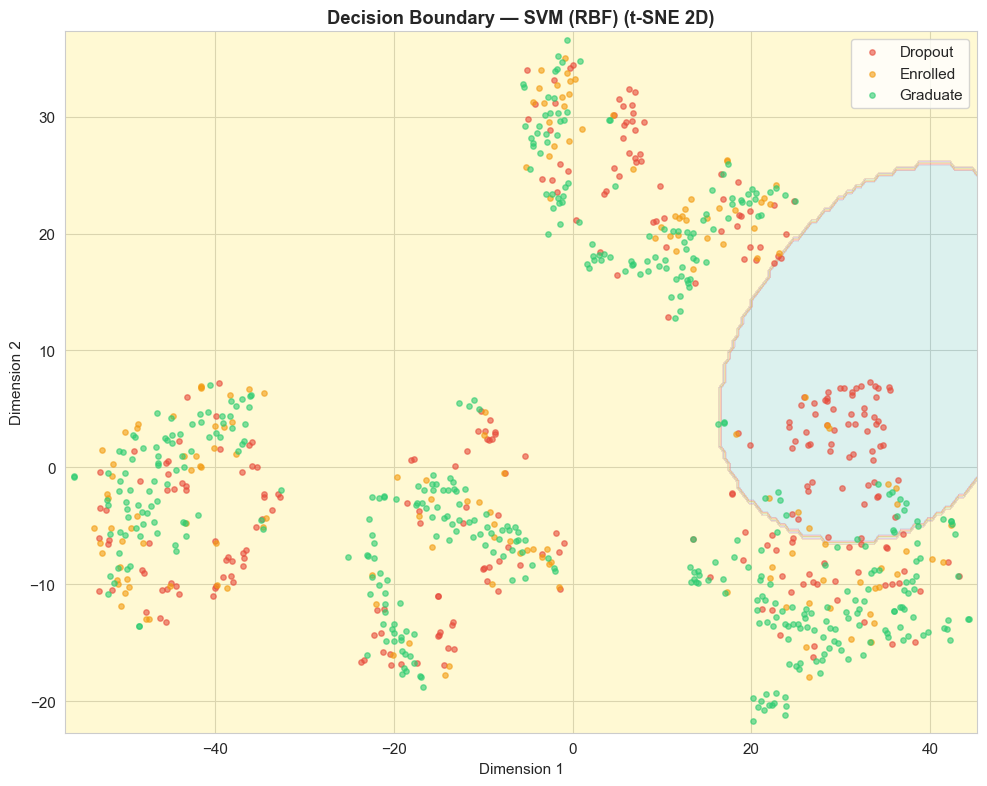

In [9]:
# t-SNE 降维到 2D 用于决策边界可视化 / t-SNE reduction to 2D for decision boundary
from sklearn.manifold import TSNE

print("运行 t-SNE... / Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_test_2d = tsne.fit_transform(X_test.values)
print(f"t-SNE 完成 / t-SNE complete: {X_test_2d.shape}")

# 在 2D 投影上训练简化模型 / Train simplified models on 2D projection
for model_name, config in [("Decision Tree", {"model_type": "dt", "max_depth": 8}),
                            ("Logistic Regression", {"model_type": "lr"}),
                            ("SVM (RBF)", {"model_type": "svm"})]:
    model_type = config.pop("model_type")
    model_2d = train_model(X_test_2d, y_test.values, model_type, **config)
    plot_decision_boundary(
        model_2d, X_test_2d, y_test.values,
        title=f"Decision Boundary — {model_name} (t-SNE 2D)",
        save_path=os.path.join(PLOT_DIR, f"04_decision_boundary_{model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.png"),
    )
    plt.show()

## 6. 模型性能对比 (Model Performance Comparison)

综合对比三种模型在不同数据集上的表现。
Comprehensive comparison of three models across different sets.

In [10]:
# 构建对比表 / Build comparison table
comparison_df = compare_models(all_results)

# 按模型分组展示 / Display grouped by model
for model_name in trained_models:
    model_rows = comparison_df[comparison_df["Model"].str.startswith(model_name)]
    print()
    print(f"{model_name}:")
    print(model_rows[["Set", "Accuracy", "F1 (macro)"]].to_string(index=False))

# 保存对比表 / Save comparison table
comparison_df.to_csv(os.path.join(project_root, "data", "model_comparison_task4.csv"), index=False)
print()
print("对比表已保存 / Comparison saved to data/model_comparison_task4.csv")


Decision Tree:
                   Set  Accuracy  F1 (macro)
 Decision Tree - Train  0.910261    0.883508
  Decision Tree - Test  0.710734    0.621088
Decision Tree - Entire  0.840868    0.793772

Logistic Regression:
                         Set  Accuracy  F1 (macro)
 Logistic Regression - Train  0.781565    0.707189
  Logistic Regression - Test  0.768362    0.697465
Logistic Regression - Entire  0.777577    0.703493

SVM (RBF):
               Set  Accuracy  F1 (macro)
 SVM (RBF) - Train  0.740522    0.649665
  SVM (RBF) - Test  0.752542    0.667681
SVM (RBF) - Entire  0.742089    0.652997

对比表已保存 / Comparison saved to data/model_comparison_task4.csv


图片已保存 / Plot saved to data/plots/04_model_comparison_f1.png


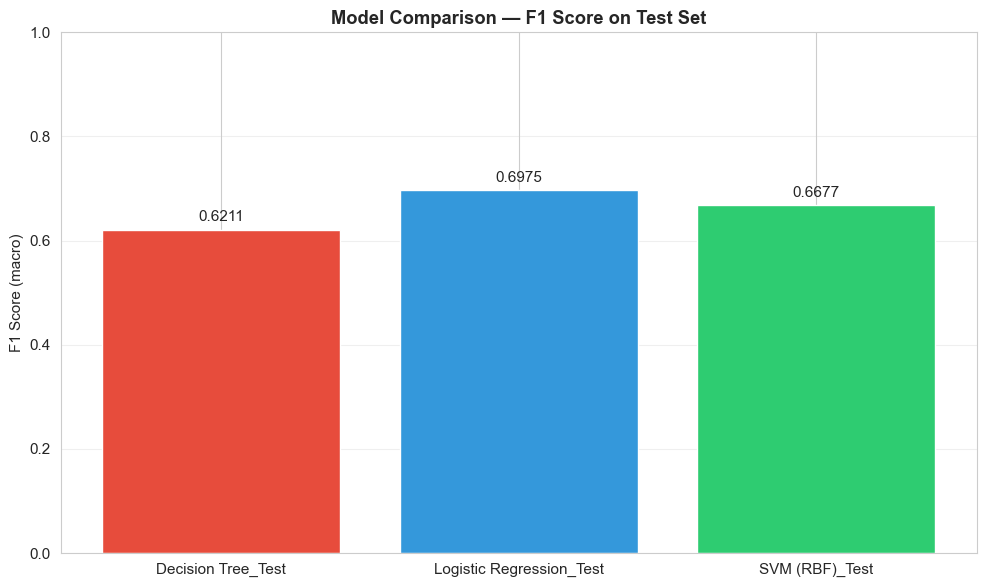

In [11]:
# 可视化对比: 测试集 F1 / Visualize comparison: test set F1
test_results = comparison_df[comparison_df["Set"].str.contains("Test")]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = ax.bar(test_results["Model"], test_results["F1 (macro)"], color=colors, edgecolor="white")
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Model Comparison — F1 Score on Test Set", fontweight="bold")
ax.set_ylim(0, 1)
for bar, val in zip(bars, test_results["F1 (macro)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_model_comparison_f1.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/04_model_comparison_f1.png")
plt.show()

## 7. 总结 (Summary)

### 发现与分析 / Findings & Analysis

- **Decision Tree**: 训练集准确率高但测试集可能下降，存在过拟合风险
- **Logistic Regression**: 作为线性模型的 baseline，表现稳定但受限于线性假设
- **SVM (RBF)**: 通过核函数处理非线性关系，通常在测试集上表现最优

三种模型将在 NB05 中进行更深入的评估（ROC/AUC、交叉验证等）。
All three models will be evaluated in depth in NB05 (ROC/AUC, cross-validation, etc.).